<a href="https://colab.research.google.com/github/Indrakaran1411/ml-learning-journey/blob/main/ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import zipfile

# This will open a file picker — select your titanic zip file
uploaded = files.upload()

# Unzip it
with zipfile.ZipFile('titanic.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/titanic')

print("Files extracted!")

Saving titanic.zip to titanic.zip
Files extracted!


In [2]:
import os
os.listdir('/content/titanic')

['train.csv', 'gender_submission.csv', 'test.csv']

In [3]:
import pandas as pd

df = pd.read_csv('/content/titanic/train.csv')
df.head()  # shows first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Shape of data
print(df.shape)

# Column info
df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Missing values
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
# Basic statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# Survival count
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)
print("Age missing:", df['Age'].isnull().sum())  # should print 0

Age missing: 0


/tmp/ipykernel_3142/245442270.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("Embarked missing:", df['Embarked'].isnull().sum())  # should print 0

Embarked missing: 0


/tmp/ipykernel_3142/3242028232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [10]:
df.drop(columns=['Cabin'], inplace=True)
print("Cabin column removed!")

Cabin column removed!


In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])  # S/C/Q → 0/1/2

df[['Sex', 'Embarked']].head()  # verify

,Sex,Embarked
0,1,2
1,0,0
2,0,2
3,0,2
4,1,2


In [13]:
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [14]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.isnull().sum()

Shape: (891, 8)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [15]:
# X = input features, y = what we want to predict
X = df.drop(columns=['Survived'])
y = df['Survived']

print("X shape:", X.shape)  # (891, 7)
print("y shape:", y.shape)  # (891,)

X shape: (891, 7)
y shape: (891,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 81.01%
Decision Tree: 78.21%
Random Forest: 82.12%


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# Use Random Forest (usually best)
rf = models["Random Forest"]
preds = rf.predict(X_test)

print(classification_report(y_test, preds, target_names=["Died", "Survived"]))

              precision    recall  f1-score   support

        Died       0.83      0.88      0.85       105
    Survived       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



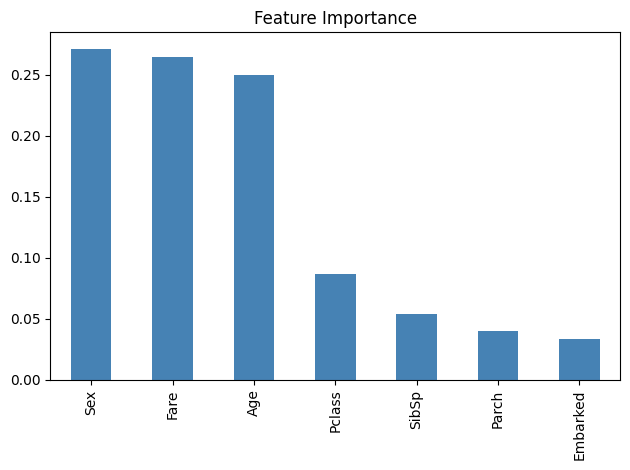

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_importance.plot(kind='bar', color='steelblue')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [21]:
# Create new smart features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # total family including self
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)  # 1 if travelling alone
df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                        labels=[0,1,2,3,4]).astype(int)  # age groups

print(df[['FamilySize', 'IsAlone', 'AgeBand']].head(10))

   FamilySize  IsAlone  AgeBand
0           2        0        2
1           2        0        3
2           1        1        2
3           2        0        2
4           1        1        2
5           1        1        2
6           1        1        3
7           5        0        0
8           3        0        2
9           2        0        1


In [22]:
X2 = df.drop(columns=['Survived'])
y2 = df['Survived']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2,
                                        test_size=0.2, random_state=42)

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X2_train, y2_train)
acc2 = accuracy_score(y2_test, rf2.predict(X2_test))

print(f"Before feature engineering: 82.12%")
print(f"After feature engineering:  {acc2*100:.2f}%")
print(f"Improvement: +{(acc2*100 - 82.12):.2f}%")

Before feature engineering: 82.12%
After feature engineering:  82.68%
Improvement: +0.56%


In [23]:
from sklearn.model_selection import GridSearchCV

# Define parameters to try
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,              # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,         # use all CPU cores
    verbose=1
)

grid_search.fit(X2_train, y2_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", f"{grid_search.best_score_*100:.2f}%")

# Test on test set
best_model = grid_search.best_estimator_
final_acc = accuracy_score(y2_test, best_model.predict(X2_test))
print("Final Test Accuracy:", f"{final_acc*100:.2f}%")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 83.56%
Final Test Accuracy: 81.56%


# ***week 2  Regression Algorithms***



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target  # target = house price (in $100,000s)

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [25]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [26]:
df.isnull().sum()


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
preds = lr.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)

print(f"MAE:   ${mae*100000:.0f}")
print(f"RMSE:  ${rmse*100000:.0f}")
print(f"R²:    {r2:.4f}")
# Scale features — IMPORTANT for regression!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

MAE:   $53320
RMSE:  $74558
R²:    0.5758
Train size: (16512, 8)
Test size:  (4128, 8)


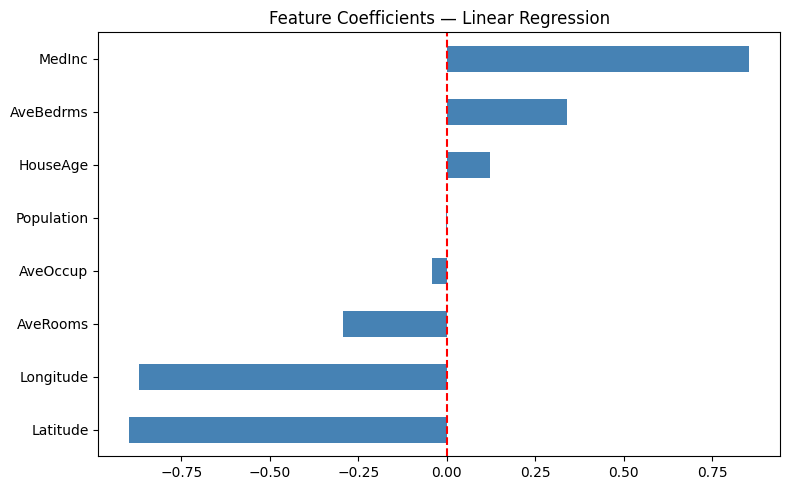

In [29]:
coefficients = pd.Series(lr.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh', color='steelblue', figsize=(8,5))
plt.title("Feature Coefficients — Linear Regression")
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1)':       Ridge(alpha=1),
    'Ridge (α=10)':      Ridge(alpha=10),
    'Lasso (α=0.1)':     Lasso(alpha=0.1),
    'Lasso (α=1)':       Lasso(alpha=1),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'MAE':   f"${mean_absolute_error(y_test, preds)*100000:.0f}",
        'RMSE':  f"${np.sqrt(mean_squared_error(y_test, preds))*100000:.0f}",
        'R²':    round(r2_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model    MAE    RMSE      R²
Linear Regression $53320  $74558  0.5758
      Ridge (α=1) $53319  $74556  0.5758
     Ridge (α=10) $53314  $74534  0.5761
    Lasso (α=0.1) $62220  $82440  0.4814
      Lasso (α=1) $90607 $114486 -0.0002


In [31]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient')

print(coef_df)
print(f"\nFeatures removed by Lasso: {(lasso.coef_ == 0).sum()}")

      Feature  Coefficient
6    Latitude    -0.011469
3   AveBedrms     0.000000
4  Population    -0.000000
2    AveRooms    -0.000000
5    AveOccup    -0.000000
7   Longitude    -0.000000
1    HouseAge     0.106453
0      MedInc     0.710598

Features removed by Lasso: 5


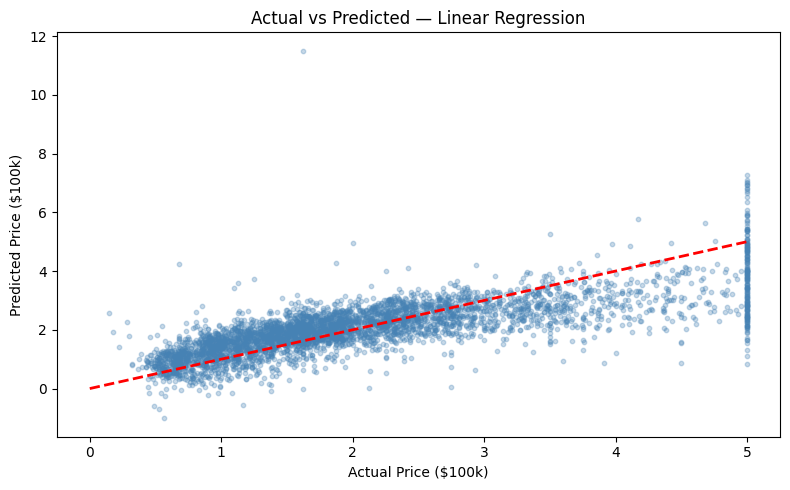

In [32]:
lr_preds = models['Linear Regression'].predict(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_preds, alpha=0.3, color='steelblue', s=10)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)  # perfect prediction line
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predicted Price ($100k)")
plt.title("Actual vs Predicted — Linear Regression")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

mae  = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2   = r2_score(y_test, rf_preds)

print(f"MAE:  ${mae*100000:.0f}")
print(f"RMSE: ${rmse*100000:.0f}")
print(f"R²:   {r2:.4f}")

MAE:  $32743
RMSE: $50514
R²:   0.8053


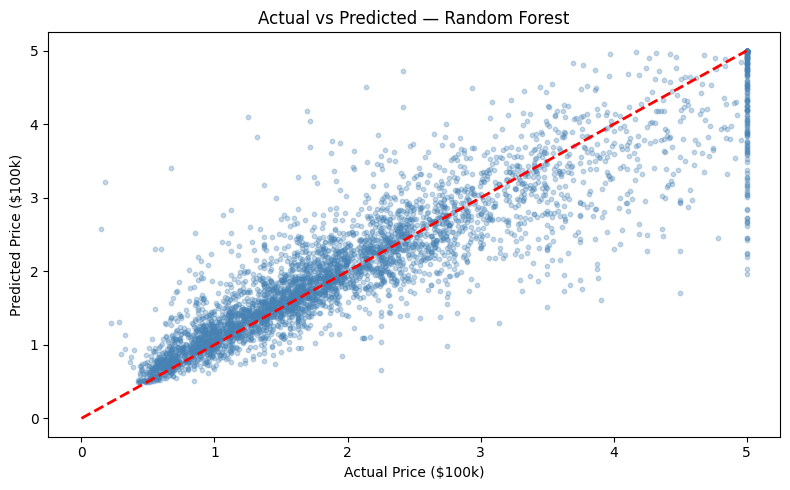

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_preds, alpha=0.3, color='steelblue', s=10)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2)
plt.xlabel("Actual Price ($100k)")
plt.ylabel("Predicted Price ($100k)")
plt.title("Actual vs Predicted — Random Forest")
plt.tight_layout()
plt.show()